In [17]:
import sys
sys.path.append("../src")
# from linear_foraging import foraging_playground_linear
import numpy as np
# from foraging_utils import optimal_linear, chance_linear, register_custom_env
import matplotlib.pyplot as plt
import gymnasium as gym
import pickle
from matplotlib.ticker import MultipleLocator
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
import torch.nn as nn
import torch
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards
import xgboost as xgb

In [18]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)

In [19]:

def reward_continious(state,upper_bound):
    return 0.2*0.1+0.8*(state/1)
def step_at_bounds(state, action, upper_bound = 0.4):
    candidate = state + action
    # If candidate goes out of bounds, stay; else move.
    if (candidate < 0) or (candidate >= upper_bound):
        return state
    return candidate


def simulate_data_raw(upper_bound = 1,delta_t = 0.01,session_duration = 10000,tdim=50, n_sessions=10,seed  = 515):
    """
    Simulate training and testing data with rewards from a given environment.


    Returns:
    - actions, state, ireward, times: np.ndarrays
    """
    ACTIONS = [-delta_t,0,delta_t]
    np.random.seed(seed)
    actions, states, irewards,times = [], [], [], []
    # state_initial = int(np.random.choice(np.arange(7)))
    state_initial = 0
    for episode in range(n_sessions):
        t = 0
        episode_data = []
        state = state_initial
        for _ in range(session_duration):
            ireward = reward_continious(state, upper_bound = upper_bound)
            # print(len(state))
            state_vec = np.array([state]).reshape(1,1)  # shape (1, state_dim)
            time_emb = time_embedding_np(t+1, tdim=tdim).reshape(1,tdim)
            # print(state_vec.shape,time_emb.shape)
            features = np.hstack([state_vec, time_emb])
            idx = np.random.randint(len(ACTIONS))
            action = ACTIONS[idx] # up,down, left right
            next_state = step_at_bounds(state, action, upper_bound=upper_bound)
            episode_data.append((action,features,ireward))
            state = next_state
            # print(state)
            t += 1
        for i, (action, features, ireward) in enumerate(episode_data):
            actions.append(action)
            states.append(features)
            irewards.append(ireward)
            times.append(i)

    return (
        np.array(actions),
        np.array(states),
        np.array(irewards),
        np.array(times),
    )

def get_candidates(state,t,upper_bound,delta_t):
    next_state = [state-delta_t, state, state+delta_t]
    if next_state[0]< 0 :
        return [state+delta_t, 0]
    elif next_state[-1] > (upper_bound+delta_t):
        return [state-delta_t, state]
    else:
        return next_state

def enumerate_paths(x0, t_inital = 0, t_prime=20,delta_t= 0.02):
    paths = [[x0]]
    for t in range(t_prime):
        new_paths = []
        for path in paths:
            curr = path[-1]
            for nxt in get_candidates(curr, t,1,delta_t):
                new_paths.append(path + [nxt])
        paths = new_paths
    
    # Convert to DataFrame: each row is one path, columns t=0..T
    cols = [f"t={t_inital+i}" for i in range(t_prime+1)]
    df = pd.DataFrame(paths, columns=cols)
    return df

In [36]:
actions, states, irewards, times = simulate_data_raw(upper_bound = 0.9,delta_t = 0.01,session_duration = 20000,tdim = 50,n_sessions = 1,seed = 517)
print(max(states[:,0,0]))

0.8900000000000006


Text(0, 0.5, 'State')

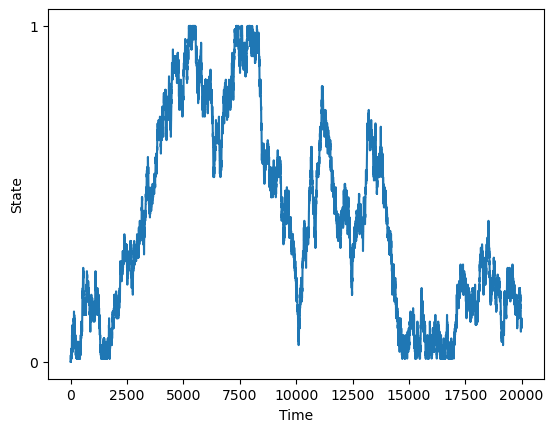

In [28]:
# plt.plot(times[:200],irewards[:200])
plt.plot(times,states[:,0,0])
plt.yticks([0,1])
plt.xlabel('Time')
plt.ylabel('State')

Text(0, 0.5, 'Reward')

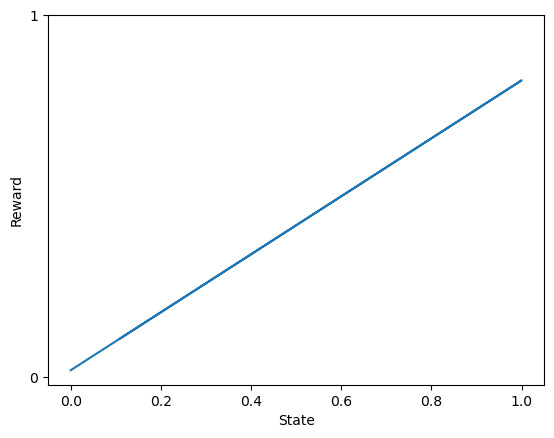

In [30]:
plt.plot(states[:,0,0],irewards)
plt.yticks([0,1])
plt.xlabel('State')
plt.ylabel('Reward')

In [37]:
T = 10000
gamma = 0.9
prewards = make_weighted_target(irewards, gamma,T = T,normalization = False)
X_train_oh = states[:T,0,:]
Y_train_value = prewards[:T]
Y_train_action = irewards[:T]
# is_pos = (Y_train_value > threshold).astype(int)
# pos = is_pos.sum()
# neg = len(Y_train_value) - pos
# w = np.where(Y_train_value > threshold, (neg / max(pos,1)), 1.0)
rf_value = xgb.XGBRegressor(
objective="reg:squarederror",
tree_method="exact", 
n_jobs = -1,
learning_rate=0.05, max_depth=10,
subsample=1, colsample_bytree=0.8,
n_estimators=2000, eval_metric="rmse")
# rf_value.fit(X_train_oh, Y_train_value, sample_weight=w)
rf_value.fit(X_train_oh, Y_train_value)


rf_action = xgb.XGBRegressor(
objective="reg:squarederror",
tree_method="exact", 
n_jobs = -1,
learning_rate=0.05, max_depth=10,
subsample=1, colsample_bytree=0.8,
n_estimators=2000, eval_metric="rmse")
rf_action.fit(X_train_oh, Y_train_action)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric='rmse', feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=2000,
             n_jobs=-1, num_parallel_tree=None, ...)

In [38]:
t_prime = 10
# current_state = states[T,0,0]
current_state = 0.5
future_states = [current_state]
print(current_state)
for delta_t in range(150):
    df_all_paths = enumerate_paths(x0=current_state,t_inital = T+delta_t,t_prime=t_prime,delta_t=0.01)
    # print(df_all_paths)
    # print(f"Total paths: {len(df_all_paths)}")
    # states_seq = df_all_paths[state_cols].to_numpy() 

    n_paths = df_all_paths.shape[0]
    irewards_pred = np.zeros((n_paths,  t_prime+1))

    for i in range(t_prime+1):
        # cand_pe = position_encoder(df_all_paths.iloc[:,i], type="onehot")
        cand_pe = np.array(df_all_paths.iloc[:,i]).reshape(-1,1)
        # print(cand_pe.shape)
        curr_time = T+1+delta_t+i
        time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
        features = np.hstack([cand_pe,time_emb])
        irewards_pred[:,i] = rf_action.predict(features)
    # # Convert to DataFrame for inspection
    reward_cols = [f"t={T+delta_t+t}" for t in range(t_prime+1)]
    df_ireward = pd.DataFrame(irewards_pred, columns=reward_cols)

    cand_pe = np.array(df_all_paths.iloc[:,-1]).reshape(-1,1)
    curr_time = T+1+delta_t+t_prime+1
    time_emb = time_embedding_np(np.ones(cand_pe.shape[0])*curr_time, tdim=50)
    features = np.hstack([cand_pe,time_emb])
    
    prewards_pred = rf_value.predict(features)
    df_ireward[f"preward"] = prewards_pred
    rewards_matrix = df_ireward.iloc[:, 1:].values  # shape (n_paths, T)
    discounts = gamma ** np.arange(0, t_prime+1)

    discounted_returns = rewards_matrix * discounts # PVAFM
    # discounted_returns = rewards_matrix[:,:-1] * discounts[:-1] 
    # total_discounted = discounted_returns.sum(axis=1)+ 7*df_ireward.iloc[:,-1].values
    # print(rewards_matrix.shape)
    # Compute discounted total reward per path
    # discounted_returns = rewards_matrix * discounts  
    total_discounted = discounted_returns.sum(axis=1)
    # print(total_discounted)
    bext_idx = np.argmax(total_discounted)
    # print(bext_idx)
    next_state = df_all_paths.iloc[bext_idx,1]
    # print(df_all_paths.iloc[bext_idx,:])
    future_states.append(next_state)
    current_state = next_state
    # print(next_state)
    print(T+delta_t+1,current_state)

0.5
10001 0.51
10002 0.52
10003 0.53
10004 0.54
10005 0.55
10006 0.56
10007 0.5700000000000001
10008 0.5800000000000001
10009 0.5900000000000001
10010 0.6000000000000001
10011 0.6100000000000001
10012 0.6200000000000001
10013 0.6300000000000001
10014 0.6400000000000001
10015 0.6500000000000001
10016 0.6600000000000001
10017 0.6700000000000002
10018 0.6800000000000002
10019 0.6900000000000002
10020 0.7000000000000002
10021 0.7100000000000002
10022 0.7200000000000002
10023 0.7300000000000002
10024 0.7400000000000002
10025 0.7500000000000002
10026 0.7600000000000002
10027 0.7700000000000002
10028 0.7800000000000002
10029 0.7900000000000003
10030 0.8000000000000003
10031 0.8100000000000003
10032 0.8200000000000003
10033 0.8300000000000003
10034 0.8400000000000003
10035 0.8500000000000003
10036 0.8600000000000003
10037 0.8700000000000003
10038 0.8800000000000003
10039 0.8900000000000003
10040 0.8900000000000003
10041 0.8900000000000003
10042 0.8900000000000003
10043 0.8900000000000003
10044

(0.5, 1.0)

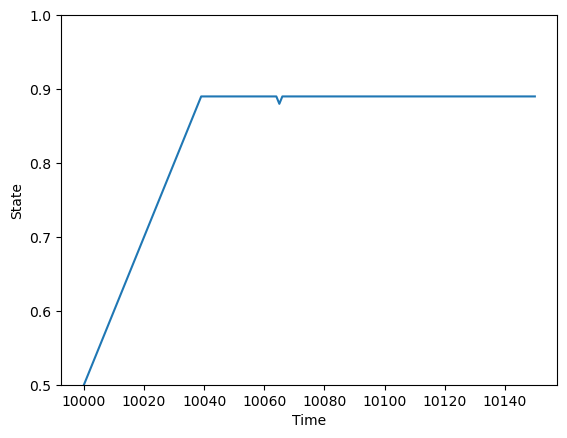

In [42]:
plt.plot(np.arange(10000,10151,1),future_states)
plt.xlabel('Time')
plt.ylabel('State')
plt.ylim([0.5,1])